In [ ]:
!pip install robustbench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.1
    Uninstalling gdown-5.2.1:
      Successfully uninstalled gdown-5.2.1
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25


In [ ]:
!pip install git+https://github.com/fra31/auto-attack

  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-ymub9d0b
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-ymub9d0b
  Resolved https://github.com/fra31/auto-attack to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Preparing metadata (setup.py) ... done
  Created wheel for autoattack: filename=autoattack-0.1-py3-none-any.whl size=36228 sha256=b52270e81d240831143cdd33cf2c2c2ec76e5e9a1d01cedfb181b1b7a84672a1
  Stored in directory: /tmp/pip-ephem-wheel-cache-5ac1jzbu/wheels/5a/06/2e/e5e2d58dcb2d67ed9e5dbbd7752368f6c68c97cd3f629ba1b4
Successfully built autoattack


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from robustbench.utils import load_model
from robustbench.data import load_cifar10
from autoattack import AutoAttack

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model_name = "Standard"  # e.g., "Rebuffi2021Fixing_70_16_cutmix_extra"
dataset = "cifar10"
threat_model = "Linf"

model = load_model(model_name=model_name, dataset=dataset, threat_model=threat_model)
model = model.to(device).eval()

print("Loaded model:", model_name)

Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=9a9338bf-8b0a-4cf9-9f39-172fcbfeb60b
To: /content/models/cifar10/Linf/Standard.pt
100%|██████████| 292M/292M [00:03<00:00, 78.1MB/s]


Loaded model: Standard


In [ ]:
N_TEST = 10000
test_images, test_labels = load_cifar10(n_examples=N_TEST)
test_images, test_labels = test_images.to(device), test_labels.to(device)

test_images.shape, test_labels.shape

100%|██████████| 170M/170M [00:04<00:00, 38.8MB/s]


(torch.Size([10000, 3, 32, 32]), torch.Size([10000]))

In [ ]:
@torch.no_grad()
def accuracy(model, x, y, batch_size=256):
    correct = 0
    n = x.shape[0]
    for i in range(0, n, batch_size):
        xb = x[i:i+batch_size]
        yb = y[i:i+batch_size]
        logits = model(xb)
        pred = logits.argmax(dim=1)
        correct += (pred == yb).sum().item()
    return correct / n

clean_acc = accuracy(model, test_images, test_labels, batch_size=256)
print(f"Clean accuracy: {clean_acc*100:.2f}%")

Clean accuracy: 94.77%


In [ ]:
epsilon = 8/255
batch_size = 128

N_EVAL = 1000
x = test_images[:N_EVAL]
y = test_labels[:N_EVAL]

adversary = AutoAttack(model, norm='Linf', eps=epsilon, version='standard', device=device)
x_adv = adversary.run_standard_evaluation(x, y, bs=batch_size)

robust_acc = accuracy(model, x_adv, y, batch_size=256)
print(f"No-defense robust accuracy (AutoAttack Linf, eps={epsilon}): {robust_acc*100:.2f}%")

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 94.80%
apgd-ce - 1/8 - 128 out of 128 successfully perturbed
apgd-ce - 2/8 - 128 out of 128 successfully perturbed
apgd-ce - 3/8 - 128 out of 128 successfully perturbed
apgd-ce - 4/8 - 128 out of 128 successfully perturbed
apgd-ce - 5/8 - 128 out of 128 successfully perturbed
apgd-ce - 6/8 - 128 out of 128 successfully perturbed
apgd-ce - 7/8 - 128 out of 128 successfully perturbed
apgd-ce - 8/8 - 52 out of 52 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 15.9 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%
No-defense robust accuracy (AutoAttack Linf, eps=0.03137254901960784): 0.00%


In [ ]:
cifar10_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

@torch.no_grad()
def pred_and_conf(model, x):
    logits = model(x)
    probs = F.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    return pred, conf

def to_img(x):
    x = x.detach().cpu().clamp(0, 1)
    return np.transpose(x.numpy(), (1, 2, 0))


In [ ]:
with torch.no_grad():
    pred_clean, conf_clean = pred_and_conf(model, x)
    pred_adv, conf_adv = pred_and_conf(model, x_adv)

changed = (pred_clean != pred_adv).nonzero(as_tuple=False).squeeze(1)
print("Num changed predictions:", changed.numel())

Num changed predictions: 948


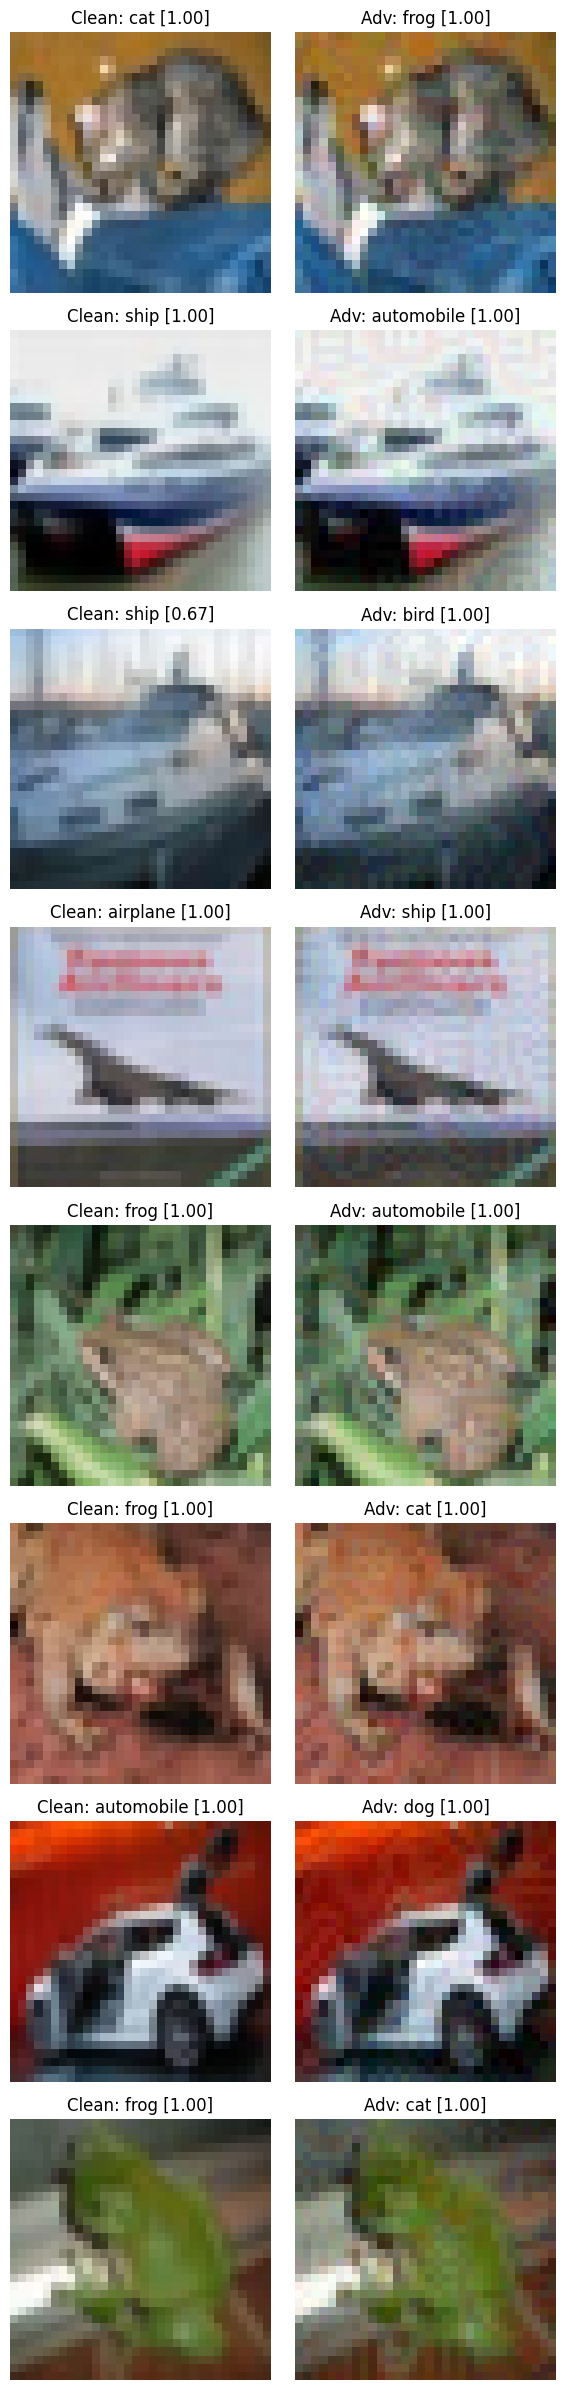

In [ ]:
# Pick a few changed examples to display
k = 8
idxs = changed[:k].tolist() if changed.numel() > 0 else list(range(min(k, x.shape[0])))

fig, axes = plt.subplots(len(idxs), 2, figsize=(6, 3*len(idxs)))
if len(idxs) == 1:
    axes = np.array([axes])

for row, idx in enumerate(idxs):
    x0 = x[idx:idx+1]
    xa = x_adv[idx:idx+1]

    pc, cc = pred_and_conf(model, x0)
    pa, ca = pred_and_conf(model, xa)
    pc, cc = pc.item(), cc.item()
    pa, ca = pa.item(), ca.item()

    axes[row, 0].imshow(to_img(x[idx]))
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Clean: {cifar10_classes[pc]} [{cc:.2f}]")

    axes[row, 1].imshow(to_img(x_adv[idx]))
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f"Adv: {cifar10_classes[pa]} [{ca:.2f}]")
    axes[row, 1].set_xlabel(f"{cifar10_classes[pc]} [{cc:.2f}] → {cifar10_classes[pa]} [{ca:.2f}]")

plt.tight_layout()
plt.show()